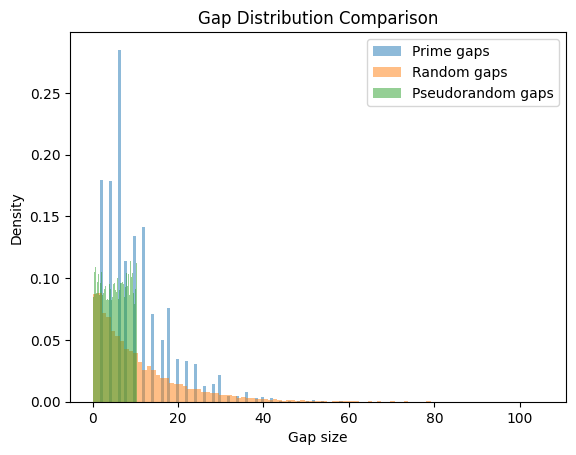


Chi-square Tests:
Prime vs Random: 6112.029643286704 p = 0.0
Prime vs Pseudo: 3439.8156107216423 p = 0.0
Random vs Pseudo: 345.8933050886739 p = 1.1750048110791325e-71

Serial Correlation:
Prime: -0.06996390271927135
Random: -0.0012993642346673616
Pseudo: -0.0010858705553732683

Entropy:
Prime: 3.588577950674199
Random: 13.227465529501673
Pseudo: 13.227465529501673


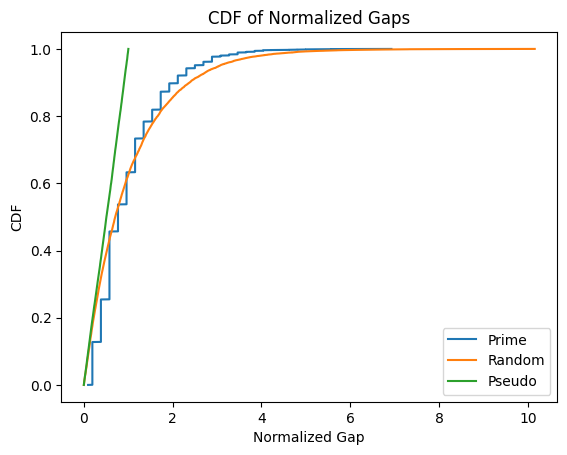


KS Tests (Normalized):
Prime vs Random: 0.1921593160254405 p = 3.492708593536416e-155
Prime vs Pseudo: 0.4187258888541341 p = 0.0
Random vs Pseudo: 0.37326660410801793 p = 0.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ---------------------------------------------------
# 1. Generate primes using sieve
# ---------------------------------------------------
def sieve_primes(n):
    is_prime = np.ones(n + 1, dtype=bool)
    is_prime[0:2] = False
    for i in range(2, int(n**0.5) + 1):
        if is_prime[i]:
            is_prime[i*i:n+1:i] = False
    return np.where(is_prime)[0]

MAX_N = 100_000
primes = sieve_primes(MAX_N)
prime_gaps = np.diff(primes)

# ---------------------------------------------------
# 2. Generate comparison models
# ---------------------------------------------------
mean_gap = np.mean(prime_gaps)

# Random exponential model
random_gaps = np.random.exponential(scale=mean_gap, size=len(prime_gaps))

# Linear congruential generator (pseudorandom)
def lcg(seed, a=1664525, c=1013904223, m=2**32):
    x = seed
    output = []
    for _ in range(len(prime_gaps)):
        x = (a * x + c) % m
        output.append(x / m)
    return np.array(output) * mean_gap

pseudo_gaps = lcg(seed=42)

# ---------------------------------------------------
# 3. Histogram comparison
# ---------------------------------------------------
plt.figure()
plt.hist(prime_gaps, bins=100, density=True, alpha=0.5, label="Prime gaps")
plt.hist(random_gaps, bins=100, density=True, alpha=0.5, label="Random gaps")
plt.hist(pseudo_gaps, bins=100, density=True, alpha=0.5, label="Pseudorandom gaps")
plt.xlabel("Gap size")
plt.ylabel("Density")
plt.title("Gap Distribution Comparison")
plt.legend()
plt.show()

# ---------------------------------------------------
# 4. Chi-square tests
# ---------------------------------------------------
def chi_square_test(data1, data2, bins):
    hist1, _ = np.histogram(data1, bins=bins)
    hist2, _ = np.histogram(data2, bins=bins)

    # Normalize hist2 to match hist1 total
    hist2 = hist2 * (hist1.sum() / hist2.sum())

    # Avoid zero expected counts
    valid = hist2 > 0
    hist1 = hist1[valid]
    hist2 = hist2[valid]

    # Final normalization
    hist2 = hist2 * (hist1.sum() / hist2.sum())

    return stats.chisquare(hist1, hist2)

# Use shared bins from prime data
hist_prime, bins = np.histogram(prime_gaps, bins=50)

chi_pr, p_pr = chi_square_test(prime_gaps, random_gaps, bins)
chi_pp, p_pp = chi_square_test(prime_gaps, pseudo_gaps, bins)
chi_rp, p_rp = chi_square_test(random_gaps, pseudo_gaps, bins)

print("\nChi-square Tests:")
print("Prime vs Random:", chi_pr, "p =", p_pr)
print("Prime vs Pseudo:", chi_pp, "p =", p_pp)
print("Random vs Pseudo:", chi_rp, "p =", p_rp)

# ---------------------------------------------------
# 5. Serial correlation
# ---------------------------------------------------
def serial_corr(x):
    return np.corrcoef(x[:-1], x[1:])[0, 1]

print("\nSerial Correlation:")
print("Prime:", serial_corr(prime_gaps))
print("Random:", serial_corr(random_gaps))
print("Pseudo:", serial_corr(pseudo_gaps))

# ---------------------------------------------------
# 6. Entropy
# ---------------------------------------------------
def entropy(data):
    values, counts = np.unique(data, return_counts=True)
    probabilities = counts / counts.sum()
    return -np.sum(probabilities * np.log2(probabilities))

print("\nEntropy:")
print("Prime:", entropy(prime_gaps))
print("Random:", entropy(random_gaps))
print("Pseudo:", entropy(pseudo_gaps))

# ---------------------------------------------------
# 7. NORMALIZATION
# ---------------------------------------------------
mean_log_p = np.mean(np.log(primes[1:]))

norm_prime = prime_gaps / mean_log_p
norm_random = random_gaps / mean_log_p
norm_pseudo = pseudo_gaps / mean_log_p

# ---------------------------------------------------
# 8. Empirical CDFs
# ---------------------------------------------------
def empirical_cdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

x_p, y_p = empirical_cdf(norm_prime)
x_r, y_r = empirical_cdf(norm_random)
x_ps, y_ps = empirical_cdf(norm_pseudo)

plt.figure()
plt.plot(x_p, y_p, label="Prime")
plt.plot(x_r, y_r, label="Random")
plt.plot(x_ps, y_ps, label="Pseudo")
plt.xlabel("Normalized Gap")
plt.ylabel("CDF")
plt.title("CDF of Normalized Gaps")
plt.legend()
plt.show()

# ---------------------------------------------------
# 9. KS tests
# ---------------------------------------------------
ks_pr, p_pr_ks = stats.ks_2samp(norm_prime, norm_random)
ks_pp, p_pp_ks = stats.ks_2samp(norm_prime, norm_pseudo)
ks_rp, p_rp_ks = stats.ks_2samp(norm_random, norm_pseudo)

print("\nKS Tests (Normalized):")
print("Prime vs Random:", ks_pr, "p =", p_pr_ks)
print("Prime vs Pseudo:", ks_pp, "p =", p_pp_ks)
print("Random vs Pseudo:", ks_rp, "p =", p_rp_ks)